In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import pmdarima as pm
import numpy as np

Loading the data and getting familiar with it.

In [17]:
data_path = 'data/IBM_2006-01-01_to_2018-01-01.csv'

df = pd.read_csv(data_path)

df.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3020.000000,3019.000000,3020.000000,3.020000e+03
mean,145.515545,146.681738,144.471597,145.617278,5.773301e+06
std,37.554946,37.613446,37.477641,37.529387,3.192831e+06
min,72.740000,73.940000,69.500000,71.740000,2.542560e+05
25%,116.405000,117.765000,115.490000,116.525000,3.622681e+06
50%,149.610000,150.330000,148.470000,149.315000,4.928852e+06
75%,178.445000,179.762500,177.330000,178.685000,6.965014e+06
max,215.380000,215.900000,214.300000,215.800000,3.077428e+07


Data preprocessing

In [18]:
# Filling missing dates with the previous day's values
first_date = df['Date'].min()
last_date = df['Date'].max()

# for single_date in pd.date_range(start=first_date, end=last_date):
#     if single_date.strftime('%Y-%m-%d') not in df['Date'].values:
#         previous_date = (single_date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
#         previous_row = df[df['Date'] == previous_date]
#         new_row = previous_row.copy()
#         new_row['Date'] = single_date.strftime('%Y-%m-%d')
#         new_row['Volume'] = 0
#         df = pd.concat([df, new_row], ignore_index=True)
# df = df.sort_values(by='Date').reset_index(drop=True)

# Find missing values in the data
missing_values = df.isnull().sum()
print("Missing values in each column:") 
print(missing_values)

# Fill missing values with previous day's values
df.fillna(method='ffill', inplace=True)

Missing values in each column:
Date      0
Open      1
High      0
Low       1
Close     0
Volume    0
Name      0
dtype: int64


C:\Users\eknut\AppData\Local\Temp\ipykernel_19960\1530574154.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Extracting trend, seasonality and residuals from the time series data.

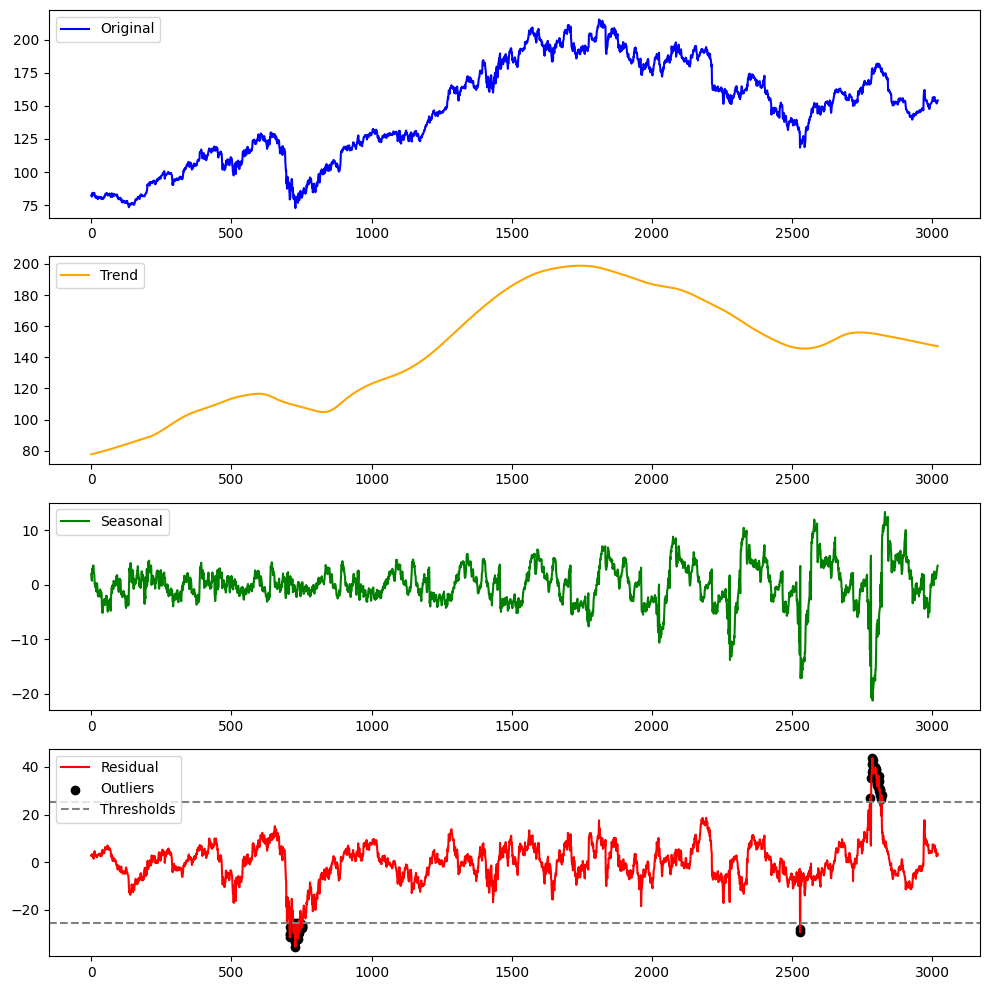

Number of outliers found: 68
Threshold: +/- 25.3331


In [19]:
# use indexes instead of dates for STL decomposition
indexes = pd.RangeIndex(start=0, stop=len(df), step=1)

series = df["Open"]

stl = STL(series, period=252, seasonal=13, robust=True)

res = stl.fit()

trend = res.trend
seasonal = res.seasonal
resid = res.resid

# Find outliers in the residuals using Z-score method
mu = resid.mean()
sigma = resid.std()
threshold = 3 * sigma

# Find Outliers
outliers = resid[np.abs(resid) > threshold]

plt.figure(figsize=(10, 10))
plt.subplot(4, 1, 1)
plt.plot(indexes, series, label='Original', color='blue')
plt.legend(loc='upper left')
plt.subplot(4, 1, 2)
plt.plot(indexes, trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(4, 1, 3)
plt.plot(indexes, seasonal, label='Seasonal', color='green')
plt.legend(loc='upper left')
plt.subplot(4, 1, 4)
plt.plot(indexes, resid, label='Residual', color='red')
plt.scatter(indexes[outliers.index], outliers, color='black', label='Outliers')
plt.axhline(y=threshold, color='gray', linestyle='--', label='Thresholds')
plt.axhline(y=-threshold, color='gray', linestyle='--')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print(f"Number of outliers found: {len(outliers)}")
print(f"Threshold: +/- {threshold:.4f}")

Plotting raw data for opening prices and volumes.

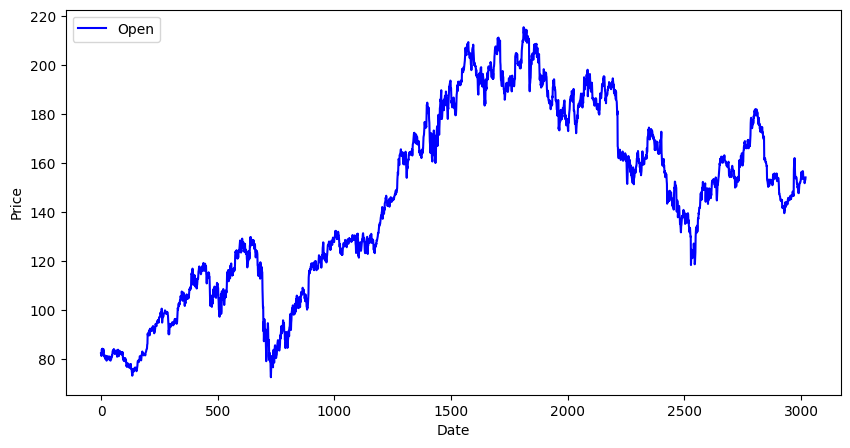

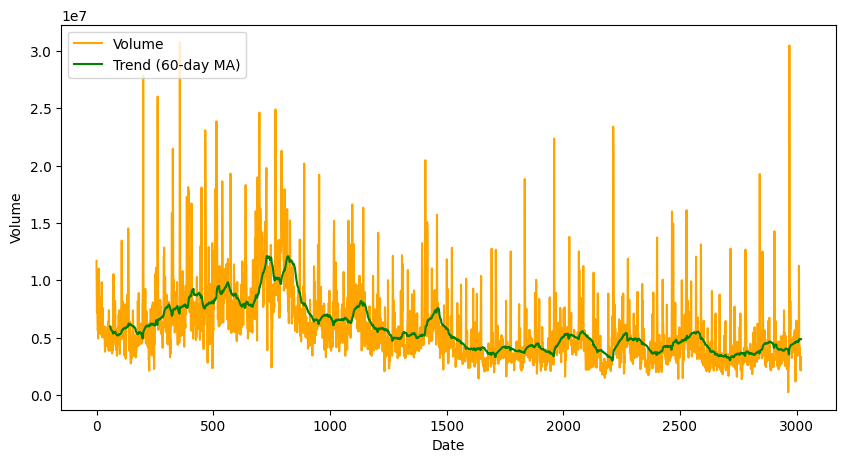

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(indexes, series, label='Open', color='blue')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend(loc='upper left')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(indexes, df['Volume'][series.index], label='Volume', color='orange')
trend_volume = df['Volume'][series.index].rolling(window=60).mean()
plt.plot(indexes, trend_volume, label='Trend (60-day MA)', color='green')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend(loc='upper left')
plt.show()

Autocorrelation analysis

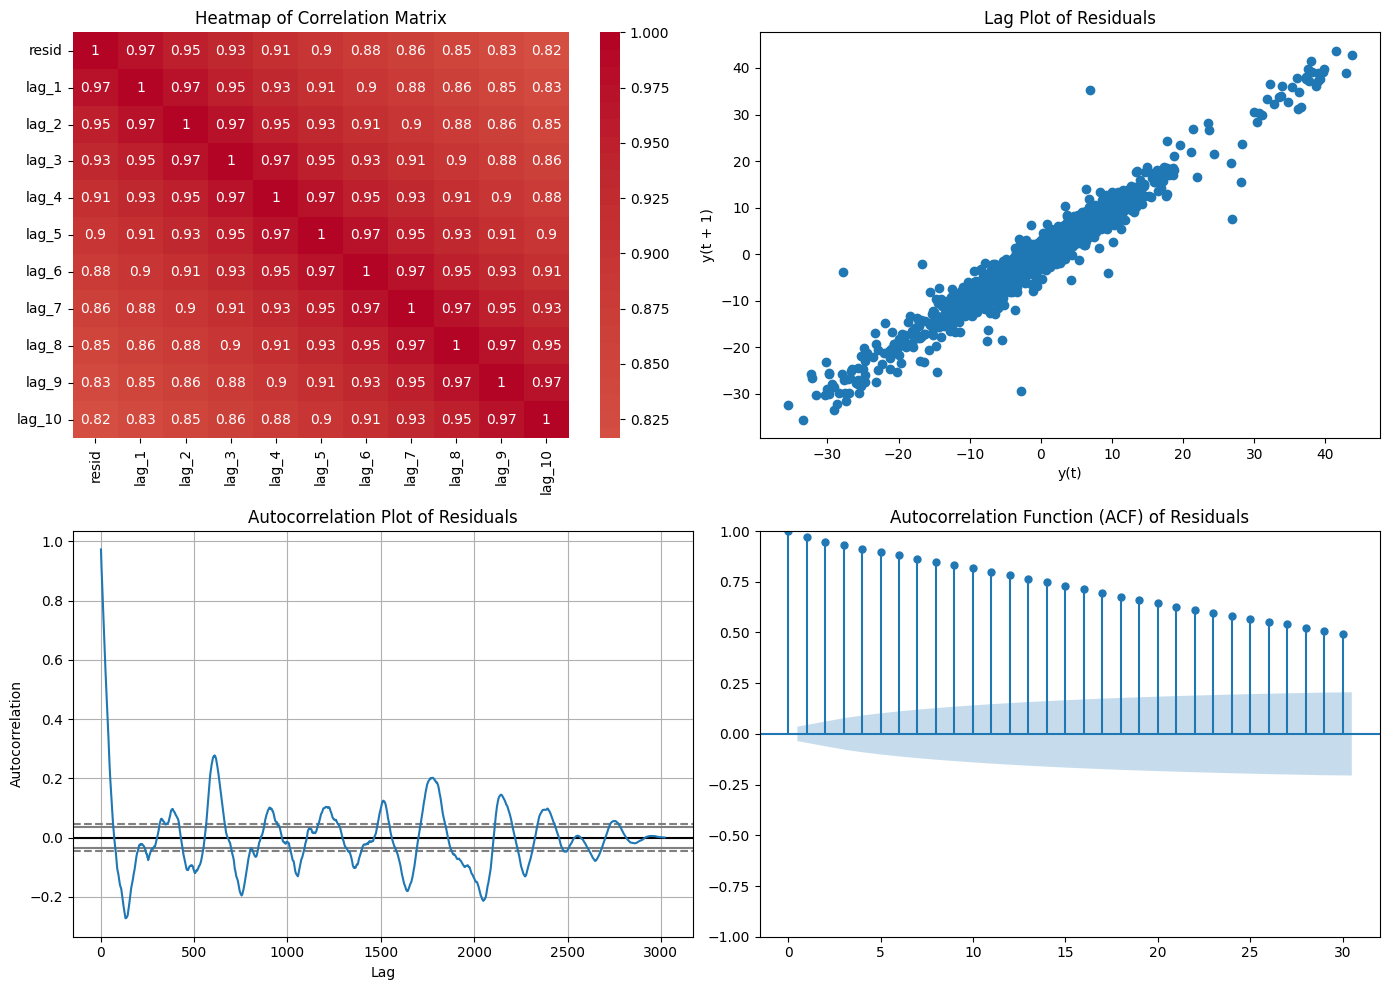

In [21]:
# Create a 1-10 day lagged dataset of the residuals
lagged_resid = pd.DataFrame({'resid': resid})
for i in range(1, 11):
    lagged_resid[f'lag_{i}'] = lagged_resid['resid'].shift(i)
lagged_resid = lagged_resid.dropna()

# Compute the correlation matrix
corr = lagged_resid.corr()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix')

# Lag plot
pd.plotting.lag_plot(resid, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Residuals')

# Autocorrelation plot
pd.plotting.autocorrelation_plot(resid, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Residuals')

# ACF (from statsmodels)
plot_acf(resid, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Residuals')

plt.tight_layout()
plt.show()

Analyze returns

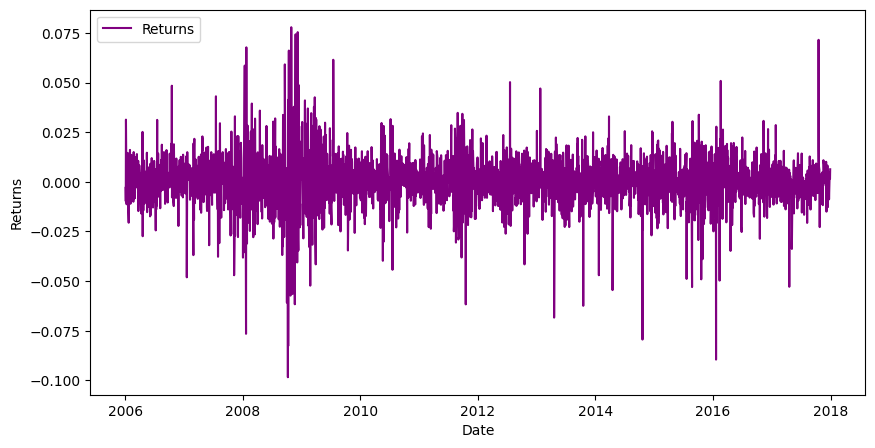

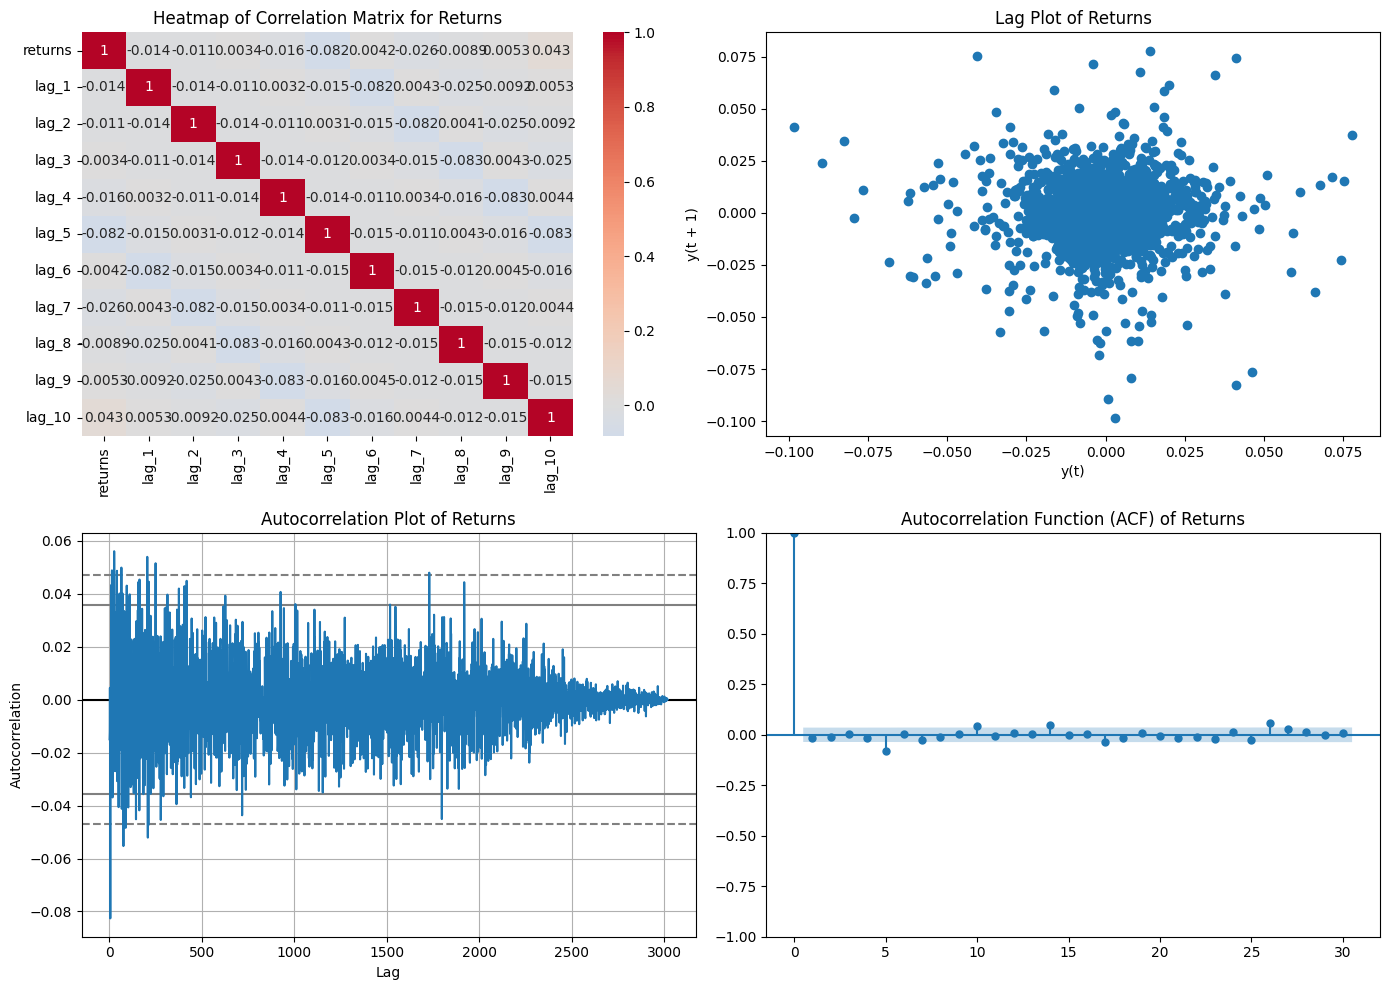

In [ ]:
# Calculate returns
returns = series.pct_change().dropna()
plt.figure(figsize=(10, 5))
plt.plot(indexes[1:], returns, label='Returns', color='purple')
# plt.title('Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

# Autocorrelation of returns
# Create a 1-10 day lagged dataset
lagged_returns = pd.DataFrame({'returns': returns})
for i in range(1, 11):
    lagged_returns[f'lag_{i}'] = lagged_returns['returns'].shift(i)
lagged_returns = lagged_returns.dropna()

# Compute the correlation matrix
corr_returns = lagged_returns.corr()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Heatmap
sns.heatmap(corr_returns, annot=True, cmap='coolwarm', center=0, ax=axes[0, 0])
axes[0, 0].set_title('Heatmap of Correlation Matrix for Returns')
# Lag plot
pd.plotting.lag_plot(returns, ax=axes[0, 1])
axes[0, 1].set_title('Lag Plot of Returns')
# Autocorrelation plot
pd.plotting.autocorrelation_plot(returns, ax=axes[1, 0])
axes[1, 0].set_title('Autocorrelation Plot of Returns')
# ACF (from statsmodels)
plot_acf(returns, lags=30, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelation Function (ACF) of Returns')
plt.tight_layout()
plt.show()

## ARIMA Model

Forecasting of the prices

In [ ]:
# Split data into training and testing sets
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

auto_model = pm.auto_arima(train,
                           start_p=1, start_q=1,
                           test='adf',       # Use 'adf' test to find the optimal 'd'
                           max_p=5, max_q=5, # Maximum p and q
                           m=7,              # Seasonality
                           d=None,           # Let the test determine 'd'
                           seasonal=True,    # Seasonality
                           start_P=0,
                           D=0,
                           trace=True,
                           error_action='ignore',
                           suppress_warnings=True,
                           stepwise=True)

# Best order
best_order = auto_model.order
print(f"Best Order: {best_order}")

# Fit ARIMA model
model = ARIMA(train, order=best_order)
model_fit = model.fit()
# Forecast
forecast = model_fit.forecast(steps=len(test))
# Plot results
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label='Train', color='blue')
plt.plot(test.index, test, label='Test', color='orange')
plt.plot(test.index, forecast, label='Forecast', color='green')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('ARIMA Model Forecast')
plt.legend()
plt.show()

# Calculate the RMSE, MAE and R2 Score
rmse = root_mean_squared_error(test, forecast)
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R2 Score: {r2}")

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=9740.501, Time=1.43 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=9745.277, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=9742.056, Time=0.28 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=9742.584, Time=0.30 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=9743.952, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=9742.173, Time=0.54 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=9740.101, Time=1.72 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=9740.239, Time=0.98 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=9741.194, Time=3.01 sec
 ARIMA(1,1,1)(1,0,2)[7] intercept   : AIC=9741.092, Time=3.71 sec
 ARIMA(1,1,1)(0,0,2)[7] intercept   : AIC=9739.573, Time=2.19 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=9740.413, Time=0.67 sec


Forecasting of the STL residuals

Best Order for Residuals: (1, 0, 1)
Best Order for Trend: (3, 1, 2)


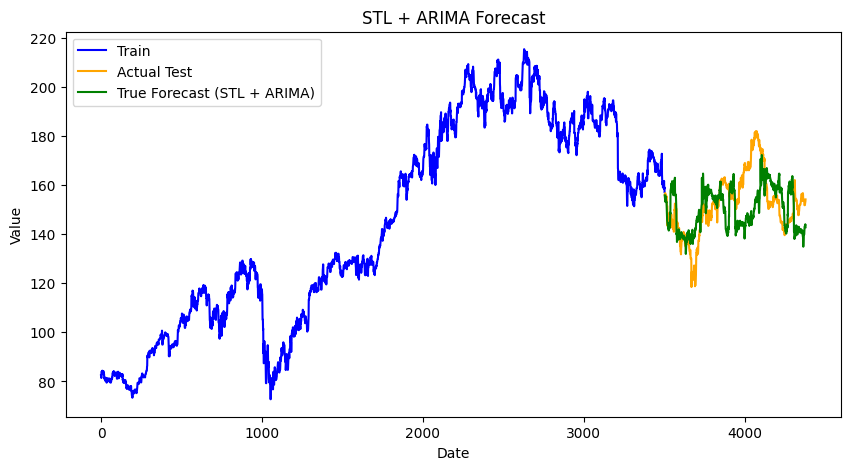

RMSE (Hybrid): 12.661073884886251
MAE (Hybrid): 10.13336773454068
R2 Score (Hybrid): -0.046127367795879115


In [ ]:
# Split data into training and testing sets
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# Original series splits
train_series, test_series = series[:train_size], series[train_size:]

period = 365
stl_train = STL(train_series, period=period, seasonal=13, robust=True)
res_train = stl_train.fit()
n_periods = len(test_series)

# ARIMA on Residuals
auto_model_resid = pm.auto_arima(res_train.resid,
                                 start_p=1, start_q=1,
                                 test='adf',
                                 max_p=5, max_q=5,
                                 m=7, seasonal=True,
                                 d=None, D=0,
                                 trace=False,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

best_order_resid = auto_model_resid.order
print(f"Best Order for Residuals: {best_order_resid}")

model_resid = ARIMA(res_train.resid, order=best_order_resid)
model_resid_fit = model_resid.fit()

resid_forecast = pd.Series(model_resid_fit.forecast(steps=n_periods), 
                             index=test_series.index)

# ARIMA on Trend
auto_model_trend = pm.auto_arima(res_train.trend,
                                 start_p=1, start_q=1,
                                 d=1,
                                 max_p=3, max_q=3,
                                 seasonal=False, # No seasonality in the trend
                                 trace=False,
                                 error_action='ignore',
                                 suppress_warnings=True,
                                 stepwise=True)

best_order_trend = auto_model_trend.order
print(f"Best Order for Trend: {best_order_trend}")

model_trend = ARIMA(res_train.trend, order=best_order_trend)
model_trend_fit = model_trend.fit()

trend_forecast = pd.Series(model_trend_fit.forecast(steps=n_periods), 
                             index=test_series.index)

# Seasonal Forecasting by repeating the last observed seasonal cycle
last_season = res_train.seasonal[-period:]
num_reps = int(np.ceil(n_periods / period))
seasonal_forecast_tiled = np.tile(last_season, num_reps)
# Trim to the exact length of the test set
seasonal_forecast = pd.Series(seasonal_forecast_tiled[:n_periods], 
                                index=test_series.index)

# Combine forecasts
total_forecast = trend_forecast + seasonal_forecast + resid_forecast

# --- 6. Plot Results ---
plt.figure(figsize=(10, 5))
plt.plot(train_series, label='Train', color='blue')
plt.plot(test_series, label='Actual Test', color='orange')
plt.plot(total_forecast, label='True Forecast (STL + ARIMA)', color='green')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('STL + ARIMA Forecast')
plt.legend()
plt.show()

# Calculate the RMSE, MAE and R2 Score for the hybrid model
rmse_hybrid = root_mean_squared_error(test_series, total_forecast)
mae_hybrid = mean_absolute_error(test_series, total_forecast)
r2_hybrid = r2_score(test_series, total_forecast)

print(f"RMSE (Hybrid): {rmse_hybrid}")
print(f"MAE (Hybrid): {mae_hybrid}")
print(f"R2 Score (Hybrid): {r2_hybrid}")